In [1]:
import torch # главная библиотека, в торче лежит всё
from torch.utils.data import Dataset, DataLoader # Dataset - хранилище данных, DataLoader - загрузчик, через который мы будем получать данные
from torch.optim import AdamW # наш оптимизатор, он смотрит на ошибку и меняет веса, чтобы сеть лучше работала
from torch.optim import Adagrad
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

import torch.nn as nn
from torch.amp import GradScaler
from torch.utils.data import random_split
from sklearn.preprocessing import TargetEncoder

In [2]:
DEVICE = torch.device("cpu") 
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")
    
get_device()

device(type='cpu')

In [3]:
data = pd.read_csv('telescope_data.csv',index_col='Unnamed: 0')
data['class'] = np.where(data['class'] == 'g', 1, 0)
data

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1
...,...,...,...,...,...,...,...,...,...,...,...
19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,0
19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,0
19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,0
19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,0


In [4]:
class TelescopeDataset(Dataset):
    def __init__(self, x, y):
        if isinstance(x, pd.DataFrame):
            self.x = x.reset_index(drop = True).values.astype(np.float32)
        elif isinstance(x, np.ndarray):
            self.x = x.astype(np.float32)
        elif isinstance(x , torch.tensor):
            self.x = x.numpy().astype(np.float32)
        else:
            self.x = np.array(x).astype(np.float32)

        if isinstance(y, (pd.Series ,pd.DataFrame)):
            self.y = y.reset_index(drop = True).values.astype(np.float32)
        elif isinstance(y, np.ndarray):
            self.y = y.astype(np.float32)
        elif isinstance(y , torch.tensor):
            self.y = y.numpy().astype(np.float32)
        else:
            self.y = np.array(y).astype(np.float32)

        if len(self.y.shape) == 1:
            self.y = self.y.reshape(-1, 1)

    def __getitem__(self, index):
        x = self.x[index]
        y = self.y[index]

        x = torch.from_numpy(x).float()
        y = torch.from_numpy(np.array([y])).float()

        return x, y
        
    def __len__(self):
        return len(self.x)

In [5]:
class Trainer():
    def __init__(self, model, device, optimizer, train_loader, val_loader):
        if isinstance(device, str):
            self.device = torch.device(device)
        else:
            self.device = device

        self.model = model.to(device)
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader

        self.use_amp = (self.device.type == "cuda")

        if self.use_amp and torch.cuda.is_bf16_supported():
            self.dtype = torch.bfloat16
        else:
            self.dtype = torch.float16
        
        self.scaler = GradScaler(enabled=(self.use_amp and torch.cuda.is_bf16_supported()))

        self.criterion = nn.MSELoss()

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        device_type = self.device.type

        for x, _ in self.train_loader:
            x = x.to(self.device)
            #target = target.to(self.device)

            self.optimizer.zero_grad(set_to_none = True)

            with torch.autocast(
                device_type = device_type,
                dtype = self.dtype,
                enabled = self.use_amp
            ):
                outputs = self.model(x)
                loss = self.criterion(outputs, x)

            self.scaler.scale(loss).backward() 
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

            self.scaler.step(self.optimizer)
            self.scaler.update()

            total_loss += loss.item()

        return total_loss / len(self.train_loader)
    
    @torch.no_grad()
    def val_epoch(self):
        self.model.eval()
        total_loss = 0 
        
        device_type = self.device.type

        for x, _ in self.val_loader:
            x = x.to(self.device)
            #target = target.to(self.device)

            with torch.autocast(
                device_type = device_type,
                dtype = self.dtype,
                enabled = self.use_amp
            ):
                outputs = self.model(x)
                loss = self.criterion(outputs, x)
        
            total_loss += loss.item()

        return total_loss / len(self.val_loader)

In [6]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim = 10, latent_dim = 4):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32,16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16,32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    def encode(self, x):
        return self.encoder(x)
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        z = self.encode(x)
        reconsructed = self.decode(z)
        return reconsructed


In [7]:
y = data['class']
x = data.drop('class', axis=1)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scale = scaler.fit_transform(X_train)
x_test_scale = scaler.transform(X_test)

train_dataset = TelescopeDataset(x_train_scale, y_train)
test_dataset = TelescopeDataset(x_test_scale, y_test)

#train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
#test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


In [8]:

#trainer_ae = Trainer(autoencode, get_device(), optimizer_ae, train_loader, test_loader)


Epoch 0: train_loss=1.0074, val_loss=1.0167
Epoch 1: train_loss=1.0010, val_loss=1.0110
Epoch 2: train_loss=0.9963, val_loss=1.0046
Epoch 3: train_loss=0.9902, val_loss=0.9969
Epoch 4: train_loss=0.9798, val_loss=0.9878
Epoch 5: train_loss=0.9718, val_loss=0.9764
Epoch 6: train_loss=0.9564, val_loss=0.9619
Epoch 7: train_loss=0.9424, val_loss=0.9463
Epoch 8: train_loss=0.9262, val_loss=0.9299
Epoch 9: train_loss=0.9088, val_loss=0.9129
Epoch 10: train_loss=0.8909, val_loss=0.8955
Epoch 11: train_loss=0.8741, val_loss=0.8773
Epoch 12: train_loss=0.8552, val_loss=0.8580
Epoch 13: train_loss=0.8365, val_loss=0.8371
Epoch 14: train_loss=0.8141, val_loss=0.8158
Epoch 15: train_loss=0.7936, val_loss=0.7943
Epoch 16: train_loss=0.7718, val_loss=0.7728
Epoch 17: train_loss=0.7501, val_loss=0.7516
Epoch 18: train_loss=0.7311, val_loss=0.7313
Epoch 19: train_loss=0.7106, val_loss=0.7122
Epoch 20: train_loss=0.6926, val_loss=0.6946
Epoch 21: train_loss=0.6752, val_loss=0.6787
Epoch 22: train_loss

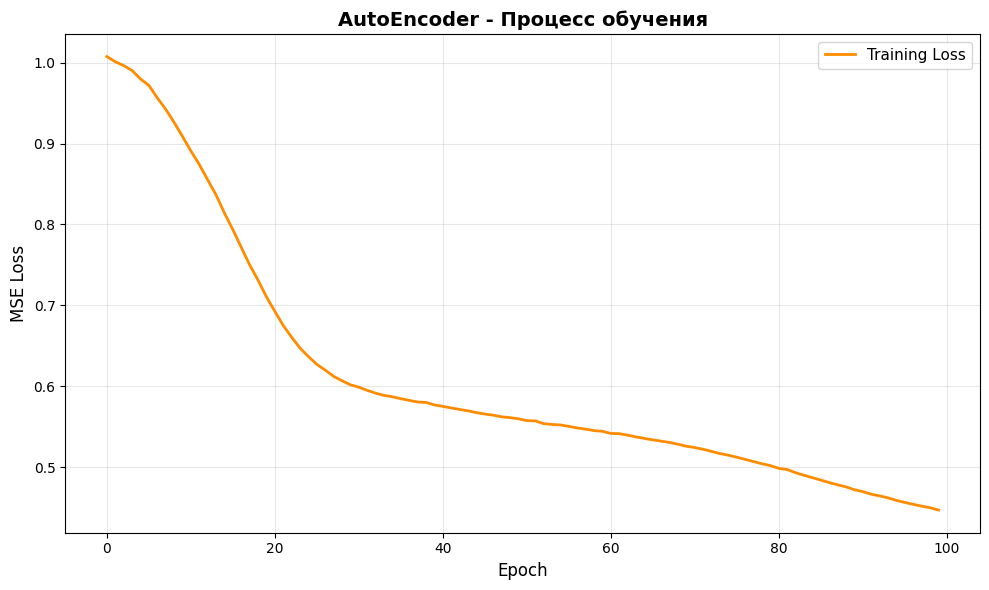

In [9]:
epoch = 100
losses = []

variables = [[512, 0.001]]
for j in range(1):
    batch_size, lr = variables[j]

    train_loader = DataLoader(train_dataset, batch_size=batch_size , shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size , shuffle=False)

    autoencode = Autoencoder(input_dim=10, latent_dim=4)
    optimizer_ae = Adagrad(autoencode.parameters(), lr=lr)

    trainer_ae = Trainer(autoencode, get_device(), optimizer_ae, train_loader, test_loader)

    for i in range(epoch):
        train_loss = trainer_ae.train_epoch()
        val_loss = trainer_ae.val_epoch()
        losses.append(train_loss)
        print(f"Epoch {i}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

    print(f'batch_size = {batch_size}  larning_rate = {lr}')

    plt.figure(figsize=(10, 6))
    plt.plot(losses, linewidth=2, label='Training Loss', color='darkorange')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('MSE Loss', fontsize=12)
    plt.title('AutoEncoder - Процесс обучения', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

    losses = []

In [11]:
# Переводим модель в режим оценки
autoencode.eval()

# Берем пример данных из тестовой выборки (например, первые 5 объектов)
# Важно: данные должны быть тензором и находиться на том же устройстве (CPU/CUDA), что и модель
sample_data = torch.from_numpy(x_test_scale[:5]).float() 

# Получаем сжатое представление
encoded_data = autoencode.encode(sample_data)

print("Оригинальная форма данных:", sample_data.shape)  # (5, 10)
print("Форма данных после кодирования:", encoded_data.shape)  # (5, 4)
print("Сжатые данные:\n", encoded_data)

Оригинальная форма данных: torch.Size([5, 10])
Форма данных после кодирования: torch.Size([5, 4])
Сжатые данные:
 tensor([[-5.7814e-01, -4.3642e-01, -3.3013e-01, -3.2704e-01],
        [-1.9457e+00, -6.7281e-01,  9.1967e-01,  1.4448e-01],
        [-1.1003e+00,  5.2322e-03, -1.1017e+00, -1.0959e+00],
        [-1.3970e+00, -5.2376e-01,  5.9541e-01,  2.6529e-02],
        [-4.9852e+00,  5.9846e+00, -9.6007e-01, -3.9249e+00]],
       grad_fn=<AddmmBackward0>)


In [12]:
# Восстановление из сжатого представления
decoded_data = autoencode.decode(encoded_data)

# Или сразу полное восстановление из исходных данных
reconstructed_data = autoencode(sample_data)

print("Восстановленные данные:\n", reconstructed_data)

Восстановленные данные:
 tensor([[-0.2802, -0.0996, -0.2293, -0.0310, -0.0057,  0.2172,  0.1591,  0.0450,
         -0.2406, -0.1198],
        [-0.7571, -0.8048, -0.9957,  1.3467,  1.2938,  0.0539, -0.2710, -0.0208,
          0.5914, -0.5644],
        [ 0.2795,  0.3671,  0.2780, -0.5636, -0.5180,  0.1148,  0.2644,  0.1709,
         -0.4297,  0.2961],
        [-0.6370, -0.6064, -0.7496,  0.8837,  0.8532,  0.1321, -0.1242, -0.0031,
          0.2882, -0.4223],
        [ 1.7261,  1.6323,  1.2427, -0.2495, -0.3053, -1.5983, -1.8200, -0.9479,
          1.3013,  0.6039]], grad_fn=<AddmmBackward0>)


Оригинальные данные:
    fLength    fWidth     fSize     fConc    fConc1     fAsym   fM3Long  \
0 -0.123166 -0.608937  0.278003 -0.101046 -0.240171  0.078177  0.425849   
1 -0.704151 -1.218286 -1.240958  1.945287  1.463727  0.021330  0.046098   
2 -0.300842 -0.151570  1.084461 -0.782250 -0.791935  0.564988  0.320251   
3 -0.866673 -0.787237 -0.568239  1.101815  1.100084  0.184895 -0.413984   
4  3.597739  0.859027  0.945854 -0.892244 -0.802736  0.851016 -4.351807   

   fM3Trans    fAlpha     fDist  
0 -0.116819 -0.023319 -0.388140  
1 -0.005865 -0.314125  0.549539  
2 -0.349655 -0.669602  0.018114  
3 -0.118015 -0.499203  0.267685  
4 -1.441358  1.246123  0.159465  

Восстановленные данные:
    fLength    fWidth     fSize     fConc    fConc1     fAsym   fM3Long  \
0 -0.280188 -0.099571 -0.229312 -0.030985 -0.005702  0.217219  0.159052   
1 -0.757118 -0.804847 -0.995685  1.346661  1.293761  0.053885 -0.271005   
2  0.279464  0.367097  0.278027 -0.563614 -0.517951  0.114849  0.264445   

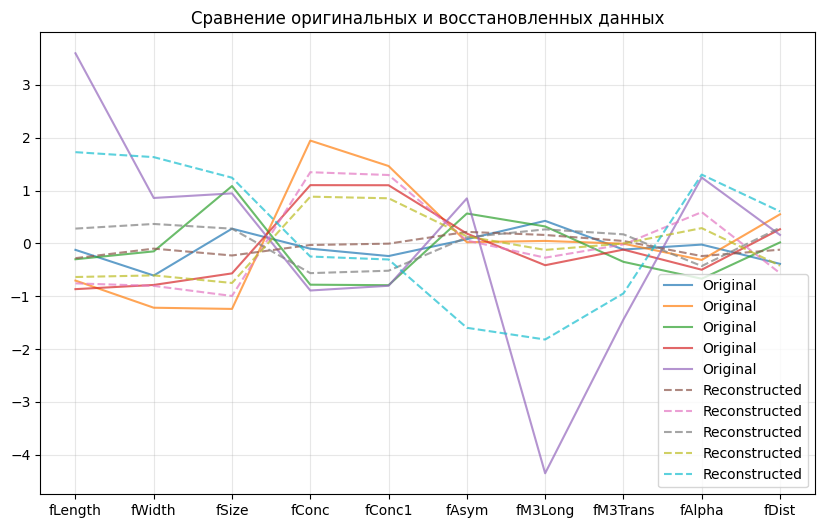

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Переводим модель в режим оценки
autoencode.eval()

# Берем пример данных из тестовой выборки
with torch.no_grad():  # Отключаем вычисление градиентов
    sample_data = torch.from_numpy(x_test_scale[:5]).float().to(DEVICE)
    
    # Получаем сжатое представление
    encoded_data = autoencode.encode(sample_data)
    
    # Получаем восстановленные данные
    reconstructed_data = autoencode(sample_data)

# Создаем DataFrame для наглядности
# Используем .detach() для тензоров с requires_grad=True
original_df = pd.DataFrame(sample_data.cpu().detach().numpy(), columns=X_train.columns)
reconstructed_df = pd.DataFrame(reconstructed_data.cpu().detach().numpy(), columns=X_train.columns)

print("Оригинальные данные:")
print(original_df)
print("\nВосстановленные данные:")
print(reconstructed_df)

# Визуализация разницы (ошибки восстановления)
plt.figure(figsize=(10, 6))
plt.plot(original_df.T, label='Original', alpha=0.7)
plt.plot(reconstructed_df.T, label='Reconstructed', linestyle='--', alpha=0.7)
plt.legend()
plt.title('Сравнение оригинальных и восстановленных данных')
plt.grid(True, alpha=0.3)
plt.show()

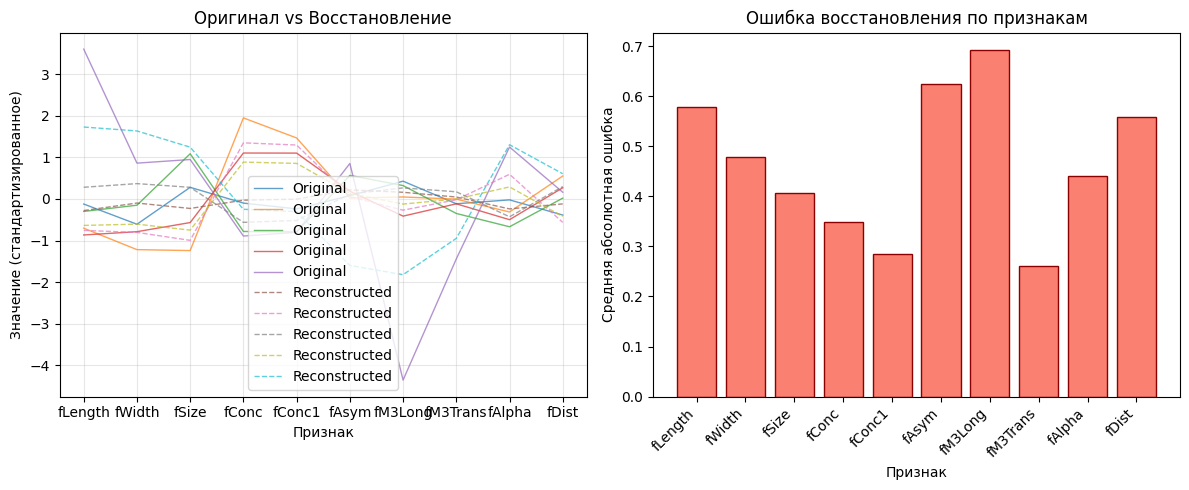

: 

In [ ]:
plt.figure(figsize=(12, 5))

# Основной график
plt.subplot(1, 2, 1)
plt.plot(original_df.T, label='Original', alpha=0.7, linewidth=1)
plt.plot(reconstructed_df.T, label='Reconstructed', linestyle='--', alpha=0.7, linewidth=1)
plt.xlabel('Признак')
plt.ylabel('Значение (стандартизированное)')
plt.title('Оригинал vs Восстановление')
plt.legend()
plt.grid(True, alpha=0.3)

# График ошибок
plt.subplot(1, 2, 2)
error = (original_df - reconstructed_df).abs().mean()
plt.bar(error.index, error.values, color='salmon', edgecolor='darkred')
plt.xlabel('Признак')
plt.ylabel('Средняя абсолютная ошибка')
plt.title('Ошибка восстановления по признакам')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()